# HumMobCov — Visualization Notebook

Produces all plots from the **already-computed** per-user parquet store.

**Pre-requisite**: run `main.ipynb` (Section 2) at least once so that the
local parquet store is populated.  This notebook never re-computes anything;
if the required data is absent it prints a clear message and skips that plot.

Controlled by:
- `src/constants.py` — global constants and directory layout
- `data/config/config_<REGION>.json` — feature flags

Sections:
1. **INPUT** — choose region, initialise store
2. **VISUALIZATION** — all metric plots
3. **GAP ANALYSIS** — methodological gap figures

---
## 0 · Imports

In [1]:
import gc
import sys
from pathlib import Path

# Make the src package importable regardless of working directory
PROJECT_ROOT = Path().resolve().parent   # HumMobCov/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import (
    # constants
    PROJECT_ROOT, LIST_REGIONS,
    # dataset classes
    DataSet_California, DataSet_Massachusets,
    # plotter
    plotter,
    # storage
    ParquetStore,
)
from src.constants import (
    DIR_MILESTONES_SERVER, DIR_OUTPUT,
    S3_ENDPOINT_URL, S3_OUTPUT_BUCKET, S3_OUTPUT_PREFIX,
)
import matplotlib.pyplot as plt

print('Project root:', PROJECT_ROOT)
print('Output dir:  ', DIR_OUTPUT)


Project root: /home/aamaduzzi/HumMobCov
Output dir:   /home/aamaduzzi/HumMobCov/output


---
## 1 · INPUT

**Edit this section** to choose which region to visualise.

In [2]:
# ─── Choose region ──────────────────────────────────────────────────────────
# Options: "CA"  (California)  or  "MA"  (Massachusetts)
REGION = "CA"

assert REGION in LIST_REGIONS, f"Unknown region '{REGION}'. Choose from {LIST_REGIONS}"

In [3]:
# ─── Optional parameter overrides ───────────────────────────────────────────
# Must match the values used when main.ipynb was run, otherwise the store
# directory names will not match and no data will be found.

OVERRIDE_NP_         = None   # e.g. 30  (minimum stops per user per period)
OVERRIDE_T_THRESHOLD = None   # e.g. 2   (minimum hours between stops)

# Plots are saved here (separate from raw data output)
PLOT_DIR = PROJECT_ROOT / "output" / REGION   # → HumMobCov/output/{REGION}/

In [4]:
# ─── Initialise dataset (metadata only — no raw data loaded) ────────────────
if REGION == "CA":
    dataset = DataSet_California()
elif REGION == "MA":
    dataset = DataSet_Massachusets()
else:
    raise ValueError(f"Unknown region {REGION!r}. Choose from {LIST_REGIONS}")

if OVERRIDE_NP_ is not None:
    dataset.np_ = OVERRIDE_NP_
if OVERRIDE_T_THRESHOLD is not None:
    dataset.t_threshold = OVERRIDE_T_THRESHOLD

print(f"Region            : {dataset.id_}")
print(f"Min points (np_)  : {dataset.np_}")
print(f"Time threshold (h): {dataset.t_threshold}")

# ─── Initialise parquet store (read-only from here) ─────────────────────────
store = ParquetStore(
    base_dir    = DIR_MILESTONES_SERVER / REGION,
    np_         = dataset.np_,
    t_threshold = dataset.t_threshold,
)
print(f"Store dir         : {store.base_dir}")


Region            : CA
Min points (np_)  : 20
Time threshold (h): 1
Store dir         : /home/aamaduzzi/HumMobCov/milestones_analysis/CA


---
## 2 · VISUALIZATION

All plots are produced from the already-saved per-user parquet files.

**If a kind is missing** (marked ✗ below) run `main.ipynb` Section 2 for the
selected region, then come back here.

In [ ]:
# ─── Data availability check — local first, then S3 consolidated ────────────
_SCALAR_KINDS = ["all_scalars", "weekly_rg", "S"]
_LONG_KINDS   = ["gonzalez", "frequency"]
_ALL_KINDS    = _SCALAR_KINDS + _LONG_KINDS

_has_s3 = bool(S3_OUTPUT_BUCKET and S3_OUTPUT_PREFIX.get(REGION))

print(f"Checking data availability for region={REGION!r} …")
print(f"  Local store : {store.base_dir}")
print(f"  S3 bucket   : {S3_OUTPUT_BUCKET if _has_s3 else '(not configured)'}")
print()

# Read-only status check: parquet footer only, O(1) per file
_status: dict = {}
for _period in dataset.period_names:
    _status[_period] = {}
    for _kind in _ALL_KINDS:
        if _kind in _SCALAR_KINDS:
            _n = len(store.get_computed_users(_period, _kind))
        else:
            _n = len(store.get_computed_users_long(_period, _kind))
        if _n:
            _status[_period][_kind] = f"local ({_n:,} users)"
        elif _has_s3:
            _status[_period][_kind] = "not local — will pull from S3 on demand"
        else:
            _status[_period][_kind] = "MISSING — run main.ipynb to compute"

print("Data status summary:")
for _period, _kinds in _status.items():
    print(f"  {_period}")
    for _kind, _msg in _kinds.items():
        _icon = "✓" if _msg.startswith("local") else ("↓" if "S3" in _msg else "✗")
        print(f"    {_icon} {_kind:20s}: {_msg}")

_any_missing_no_s3 = any(
    "MISSING" in msg
    for row in _status.values()
    for msg in row.values()
)
if _any_missing_no_s3:
    print()
    print("⚠  Some data is missing and S3 is not configured.")
    print("   Run main.ipynb to compute the data, then re-run this notebook.")

# ─── Helper: ensure kind is available locally, pulling from S3 if needed ────
def _ensure_kind(*kinds: str) -> bool:
    """
    Make sure every requested kind is available in the local store for all
    periods.

    Priority:
      1. Already in the local store → nothing to do.
      2. Not local but S3 is configured → pull consolidated.parquet from S3
         just-in-time (keeps peak RAM bounded: the S matrix is only fetched
         immediately before plot_St and released right after).
      3. Neither local nor on S3 → print a warning and return False so the
         calling plot cell is skipped gracefully.

    Returns True when the data is ready, False when the plot should be skipped.
    """
    for _kind in kinds:
        for _period in dataset.period_names:
            if _kind in _SCALAR_KINDS:
                _already = bool(store.get_computed_users(_period, _kind))
            else:
                _already = bool(store.get_computed_users_long(_period, _kind))
            if _already:
                continue
            if _has_s3:
                print(f"  Pulling {_kind!r} / {_period!r} from S3 …")
                store.pull_period_from_s3(
                    period       = _period,
                    kind         = _kind,
                    s3_bucket    = S3_OUTPUT_BUCKET,
                    s3_prefix    = S3_OUTPUT_PREFIX[REGION],
                    endpoint_url = S3_ENDPOINT_URL,
                    verbose      = True,
                )
                # Verify the pull actually delivered data
                if _kind in _SCALAR_KINDS:
                    _ok = bool(store.get_computed_users(_period, _kind))
                else:
                    _ok = bool(store.get_computed_users_long(_period, _kind))
                if not _ok:
                    print(f"  ✗ Pull failed for {_kind!r} / {_period!r}.")
                    print(f"    Run main.ipynb to (re-)compute this data.")
                    return False
            else:
                print(f"  ⚠  '{_kind}' / '{_period}' is not in the local store")
                print(f"     and S3 is not configured.")
                print(f"     → Run main.ipynb to compute this data, then re-run here.")
                return False
    return True

# ─── Initialise plotter ──────────────────────────────────────────────────────
plt_obj = plotter(
    np_             = dataset.np_,
    period_division = dataset.period_division,
    period_names    = dataset.period_names,
    t_threshold     = dataset.t_threshold,
    region          = REGION,
    county2party    = dataset.county2party,
    df_rurality     = dataset.df_rurality,
    output_dir      = PLOT_DIR,
    store           = store,
)
print("\nPlotter ready.")
if _has_s3:
    print("Missing kinds will be pulled from S3 one at a time as each plot runs.")


Checking data availability for region='CA' …
  Local store : /home/aamaduzzi/HumMobCov/milestones_analysis/CA
  S3 bucket   : chub-datalake



### 2.1 Radius of Gyration

In [ ]:
if _ensure_kind("all_scalars"):
    plt_obj.plot_rg()
plt.close("all"); gc.collect()

### 2.2 Weekly Radius of Gyration

In [ ]:
if _ensure_kind("weekly_rg", "all_scalars"):
    plt_obj.plot_rg_rurality_weekly()
plt.close("all"); gc.collect()

In [ ]:
if _ensure_kind("weekly_rg", "all_scalars"):
    plt_obj.plot_rg_party_weekly()
plt.close("all"); gc.collect()

### 2.3 k-Radius of Gyration

In [ ]:
if _ensure_kind("all_scalars"):
    plt_obj.plot_krg()
plt.close("all"); gc.collect()

### 2.4 Distance

In [ ]:
if _ensure_kind("all_scalars"):
    plt_obj.plot_distance()
plt.close("all"); gc.collect()

### 2.5 Entropy

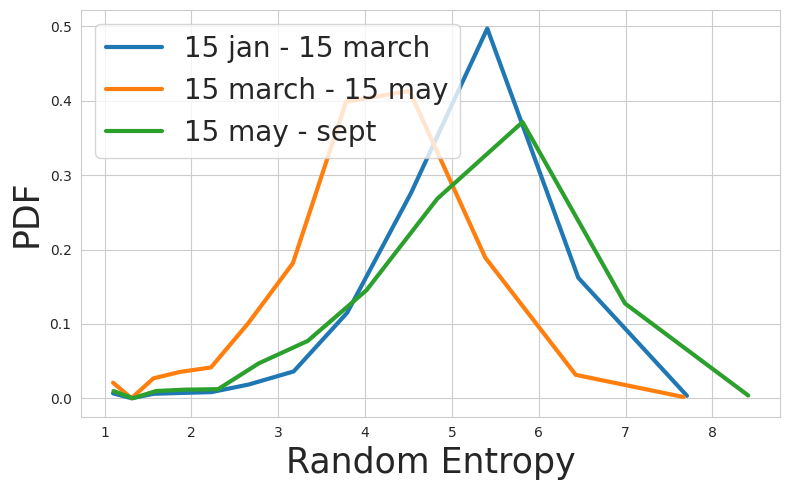

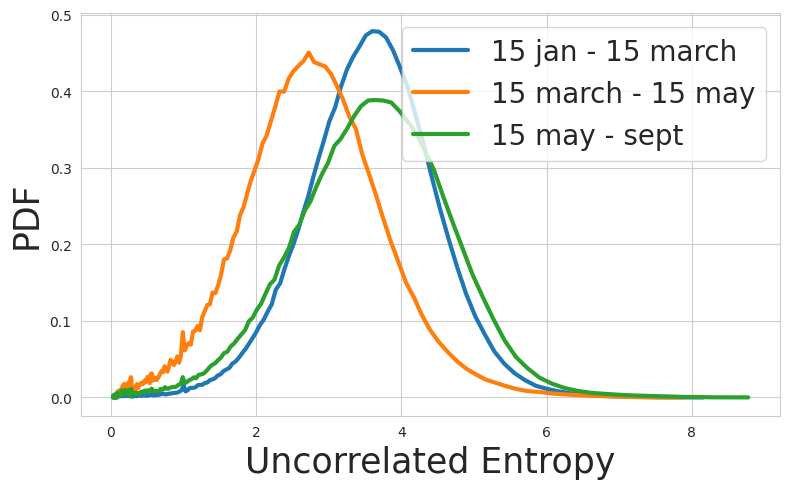

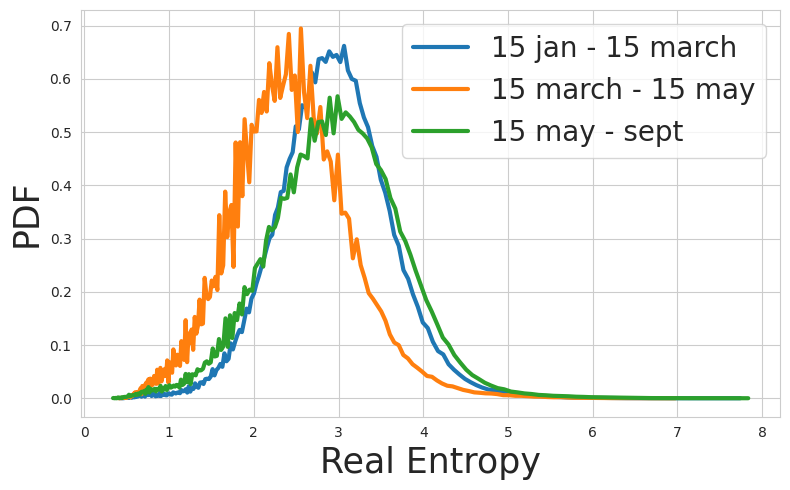

9080

In [ ]:
if _ensure_kind("all_scalars"):
    plt_obj.plot_entropy()
plt.close("all"); gc.collect()

### 2.6 Exploration Curve S(t)

In [ ]:
if _ensure_kind("S"):
    plt_obj.plot_St()
plt.close("all"); gc.collect()

### 2.7 Location Frequency

In [ ]:
if _ensure_kind("frequency"):
    plt_obj.plot_frequency()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'frequency' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0

### 2.8 Gonzalez Trajectory Shape

In [ ]:
if _ensure_kind("gonzalez"):
    plt_obj.plot_gonzalez()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'gonzalez' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0

In [ ]:
if _ensure_kind("gonzalez"):
    plt_obj.plot_sigmaxy()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'gonzalez' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0

In [ ]:
import polars as pl
pl.read_parquet("/home/aamaduzzi/HumMobCov/output/CA/plot_data/k_radius_gyration_distribution_np20_t1_CA.parquet")

period,k,rg,rg_k
str,i64,f64,f64
"""15 march - 15 may""",3,33.971509,0.048488
"""15 march - 15 may""",3,25.469868,13.286377
"""15 march - 15 may""",3,3.865476,0.213545
"""15 march - 15 may""",3,2.014867,0.114817
"""15 march - 15 may""",3,4.749012,0.630018
…,…,…,…
"""15 may - sept""",10,6.470044,6.195843
"""15 may - sept""",10,6.15154,2.458629
"""15 may - sept""",10,36.133898,1.3707


---
## 3 · GAP ANALYSIS — Methodological improvements

Four standalone plot functions that address scientific gaps in the paper:

| # | Gap | Function |
|---|-----|----------|
| 1 | **Causal framing** — NPIs vs. voluntary behaviour | `plot_gap1_npi_timeline` |
| 2 | **Sampling bias** — opt-in skew quantified | `plot_gap2_sampling_bias` |
| 3 | **Party/rurality conflation** — partial correlations + OLS | `plot_gap3_party_rurality` |
| 4 | **Post-lockdown asymmetry** — explicitly shown in Results | `plot_gap4_post_lockdown_asymmetry` |

### 3.1 Gap 1 — Causal framing: NPI event timeline

Overlays formal government-order dates on the weekly RG time-series.

In [ ]:
if _ensure_kind("weekly_rg"):
    fig_gap1 = plt_obj.plot_gap1_npi_timeline(save=True)
    plt.show()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'weekly_rg' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0

### 3.2 Gap 2 — Sampling bias quantification

Compares the number of users per county to the census population.

In [ ]:
if _ensure_kind("all_scalars"):
    fig_gap2 = plt_obj.plot_gap2_sampling_bias(save=True)
    plt.show()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'all_scalars' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0

### 3.3 Gap 3 — Party / rurality conflation

In [ ]:
if _ensure_kind("all_scalars"):
    fig_gap3_rg = plt_obj.plot_gap3_party_rurality(metric='radius_gyration', save=True)
    plt.show()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'all_scalars' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0

### 3.4 Gap 4 — Post-lockdown asymmetry

In [ ]:
if _ensure_kind("all_scalars"):
    fig_gap4_rg = plt_obj.plot_gap4_post_lockdown_asymmetry(metric='radius_gyration', save=True)
    plt.show()
plt.close("all"); gc.collect()

  ⚠  Skipping plot: 'all_scalars' / '15 jan - 15 march' not in local store.
     Run main.ipynb Section 2 for region='CA' to compute it.


0